# Museum Classifier — Supervised: Decision Tree + Gradient Boosting

**Preprocessing pipeline:**
- **Pipeline A** — ResNet18 (pretrained CNN feature extractor) → 512-d vectors

**Steps:**
1. Image Preprocessing — ResNet18 features extracted
2. Modeling × 5 — five Gradient Boosting + DT configs (plus 2 plain DT baselines)
3. Report — metrics, ROC, CV F1, summary table

**Dataset structure on Google Drive:**
```
MyDrive/appliedAI/
├── training/
│   ├── museum-indoor/
│   └── museum-outdoor/
├── museum_validation/
│   ├── museum-indoor/
│   └── museum-outdoor/
└── test/
```

In [ ]:
# Install missing packages (run once)
!pip install -q scikit-image opencv-python-headless torch torchvision

## Environment Setup

Run this notebook **locally** or on **Google Colab** — the cell below detects the environment automatically.

- **Local**: uses `~/Documents/Prog/AppliedAI` as the base folder
- **Colab**: mounts Google Drive and uses `MyDrive/appliedAI` — upload your dataset there first

In [1]:
import os, sys, time, warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay,
                             precision_score, recall_score)
from sklearn.preprocessing import StandardScaler

from skimage.feature import hog, local_binary_pattern
from skimage import color as skcolor
import cv2

%matplotlib inline
warnings.filterwarnings("ignore")
import joblib

In [2]:
import os

def _in_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

if _in_colab():
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = Path('/content/drive/MyDrive/appliedAI')  # ← adjust Drive path if needed
else:
    BASE_DIR = Path.home() / 'Documents' / 'Prog' / 'AppliedAI'  # local path

print(f'Running in: {"Google Colab" if _in_colab() else "local"} environment')
print(f'BASE_DIR: {BASE_DIR}')

Mounted at /content/drive
Running in: Google Colab environment
BASE_DIR: /content/drive/MyDrive/appliedAI


## Configuration

Adjust `BASE_DIR` to point to your dataset folder inside Google Drive if needed.

In [3]:
TRAIN_DIR  = BASE_DIR / 'training'
VAL_DIR    = BASE_DIR / 'museum_validation'
TEST_DIR   = BASE_DIR / 'test'
OUTPUT_DIR = BASE_DIR / 'outputs_supervised'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASSES      = ['museum-indoor', 'museum-outdoor']   # must match folder names
IMG_SIZE     = 224
BATCH_SIZE   = 32
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'
RANDOM_STATE = 42

print(f'Training dir    : {TRAIN_DIR}')
print(f'Validation dir  : {VAL_DIR}')
print(f'Test dir        : {TEST_DIR}')
print(f'Device          : {DEVICE}')
CHECKPOINT_DIR = BASE_DIR / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Checkpoint file paths — delete a file to force recomputation of that step
CKPT_RESNET_TRAIN = CHECKPOINT_DIR / 'sup_resnet_train.npz'
CKPT_RESNET_VAL   = CHECKPOINT_DIR / 'sup_resnet_val.npz'
# Bumped to _gb after AdaBoost→GradientBoosting migration (invalidates old cache)
CKPT_MODELS_R     = CHECKPOINT_DIR / 'sup_models_resnet_gb.joblib'

# HOG baseline checkpoints — features (.npz) and trained DT (.joblib) on Drive
CKPT_HOG_TRAIN    = CHECKPOINT_DIR / 'sup_hog_train.npz'
CKPT_HOG_VAL      = CHECKPOINT_DIR / 'sup_hog_val.npz'
CKPT_HOG_DT       = CHECKPOINT_DIR / 'sup_hog_dt.joblib'
CKPT_HOG_DT_DEEP  = CHECKPOINT_DIR / 'sup_hog_dt_deep.joblib'
# NOTE: if you change HOG_IMG_SIZE or HOG_PARAMS, delete the .npz files
# above manually from Drive to force re-extraction with the new config.


Training dir    : /content/drive/MyDrive/appliedAI/training
Validation dir  : /content/drive/MyDrive/appliedAI/museum_validation
Test dir        : /content/drive/MyDrive/appliedAI/test
Device          : cpu


## Dataset Loader

In [4]:
class MuseumDataset(Dataset):
    """Loads labeled images from a root folder containing one sub-folder per class."""
    def __init__(self, root: Path, classes: list, transform=None):
        self.samples, self.transform = [], transform
        for idx, cls in enumerate(classes):
            d = root / cls
            if not d.exists():
                print(f'[WARN] Folder not found: {d}'); continue
            for ext in ('*.jpg', '*.jpeg', '*.png', '*.bmp', '*.webp'):
                for p in d.glob(ext):
                    self.samples.append((p, idx))
        # Sort by path to guarantee deterministic ordering across sessions.
        # d.glob() order is filesystem-defined; without sorting, loading one
        # feature checkpoint from a previous Colab session while re-extracting
        # the other can produce mismatched (feature, label) pairs that the
        # label-equality assertion may not catch on a balanced dataset.
        self.samples.sort(key=lambda x: str(x[0]))
        counts = {cls: sum(1 for _, l in self.samples if l == i)
                  for i, cls in enumerate(classes)}
        print(f'  {root.name}: {len(self.samples)} images — ' +
              ', '.join(f'{cls}={n}' for cls, n in counts.items()))

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

In [5]:
# =====================================================================
# TRAIN / VAL / TEST split — physical separation on disk
# - TRAIN_DIR  -> training/           (used to fit the model, 100%)
# - VAL_DIR    -> museum_validation/  (held-out, only used to score)
# - TEST_DIR   -> test/               (unlabeled, only for final prediction)
# The three folders are independent: no image file is shared between
# them. The split is therefore NOT done programmatically, it is enforced
# by the dataset structure provided by the assignment.
# =====================================================================
print('Loading datasets...')
train_dataset = MuseumDataset(TRAIN_DIR, CLASSES)   # <-- only training/
val_dataset   = MuseumDataset(VAL_DIR,   CLASSES)   # <-- only museum_validation/

if len(train_dataset) == 0:
    raise RuntimeError('No training images found - check TRAIN_DIR.')
if len(val_dataset) == 0:
    raise RuntimeError('No validation images found - check VAL_DIR.')


Loading datasets...
  training: 10000 images — museum-indoor=5000, museum-outdoor=5000
  museum_validation: 200 images — museum-indoor=100, museum-outdoor=100


## Step 1-A — Image Preprocessing: ResNet18 (512-d)

Pretrained ResNet18 with the classification head replaced by `nn.Identity()` acts as a frozen
feature extractor. Each image is resized to 224×224, normalized with ImageNet statistics,
and produces a 512-dimensional embedding. Run separately on training and validation sets.

In [6]:
import os

def _load_npz(path):
    d = np.load(path)
    return d['X'], d['y']

def _save_npz(path, X, y):
    np.savez_compressed(path, X=X, y=y)
    print(f'  [CKPT] Saved → {path}')

def extract_resnet_features(dataset, ckpt_path=None):
    """
    Extract 512-d feature vectors using a frozen pretrained ResNet18.
    The classification head is replaced with nn.Identity(); the backbone
    runs in eval mode with torch.no_grad() — no backpropagation occurs.

    Note on data augmentation:
    Augmentation (flipping, jitter, rotation) only provides real benefit
    during fine-tuning, where each training epoch forces the model to learn
    invariances through gradient updates. Here the network is frozen —
    applying augmentation would only produce a slightly different 512-d
    vector for the same image, with no benefit for the downstream
    Gradient Boosting / Decision Tree classifier.

    Required preprocessing:
    - Resize 224x224: the spatial scale for which ImageNet filters were calibrated
    - Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]): input
      distribution expected by the pretrained weights

    Checkpoint: if ckpt_path is provided and exists, features are loaded
    from disk instead of being recomputed. Delete the file to force
    re-extraction.
    """
    if ckpt_path and ckpt_path.exists():
        print(f'  Loading from checkpoint: {ckpt_path.name}')
        X, y = _load_npz(ckpt_path)
        print(f'    shape={X.shape}')
        return X, y
    resnet_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    dataset.transform = resnet_transform
    backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    backbone.fc = nn.Identity()
    backbone.eval().to(DEVICE)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    feats_list, labels_list = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            feats_list.append(backbone(imgs.to(DEVICE)).cpu().numpy())
            labels_list.append(lbls.numpy() if isinstance(lbls, torch.Tensor)
                               else np.array(lbls))
    dataset.transform = None
    X = np.concatenate(feats_list)
    y = np.concatenate(labels_list)
    print(f'    shape={X.shape}')
    if ckpt_path:
        _save_npz(ckpt_path, X, y)
    return X, y

print('[STEP 1-A] Extracting ResNet18 features...')
print('  Training set:')
X_resnet_train, y_train = extract_resnet_features(train_dataset, CKPT_RESNET_TRAIN)
print('  Validation set:')
X_resnet_val,   y_val   = extract_resnet_features(val_dataset,   CKPT_RESNET_VAL)

[STEP 1-A] Extracting ResNet18 features...
  Training set:
  Loading from checkpoint: sup_resnet_train.npz
    shape=(10000, 512)
  Validation set:
  Loading from checkpoint: sup_resnet_val.npz
    shape=(200, 512)


## Step 1-B (Baseline) — HOG features + Decision Tree

**Goal:** justify the use of ResNet18 as feature extractor.

We compare the **same simple model** (`DecisionTreeClassifier(max_depth=2, gini)`) trained on two
different feature spaces:

- **HOG** — classical handcrafted descriptor, no learning involved (~1.7k dims on 128×128 grayscale).
- **ResNet18** — 512-d embedding from a CNN pretrained on ImageNet (already extracted in Step 1-A).

Since the classifier and the data are identical, **any performance gap isolates the contribution
of the feature representation itself**.

**Checkpointing:** HOG features are saved to `sup_hog_train.npz` / `sup_hog_val.npz`, and the
trained DT to `sup_hog_dt.joblib`. Subsequent runs skip extraction *and* training.


[STEP 1-B] Extracting HOG features...
  Training set:
  Loading from checkpoint: sup_hog_train.npz
    shape=(10000, 1764)
  Validation set:
  Loading from checkpoint: sup_hog_val.npz
    shape=(200, 1764)

[STEP 1-B] Training comparison models...

  -- DT(max_depth=2) on HOG --
  [HOG d=2] Loading from checkpoint: sup_hog_dt.joblib

  -- DT(max_depth=None) on HOG --
  [HOG d=inf] Loading from checkpoint: sup_hog_dt_deep.joblib

  -- DT(max_depth=2) on ResNet --
  [ResNet d=2] Trained in 6.5s  (effective depth=2, leaves=4)

  -- DT(max_depth=None) on ResNet --
  [ResNet d=inf] Trained in 40.7s  (effective depth=48, leaves=306)

  Feature comparison — same model, two capacity levels
Model                 Feature                    dim       Acc        F1       AUC
------------------------------------------------------------------------------
DT (max_depth=2)      HOG (handcrafted)         1764    0.5950    0.5837    0.6335
DT (max_depth=2)      ResNet18 (pretrained)      512    0.9150  

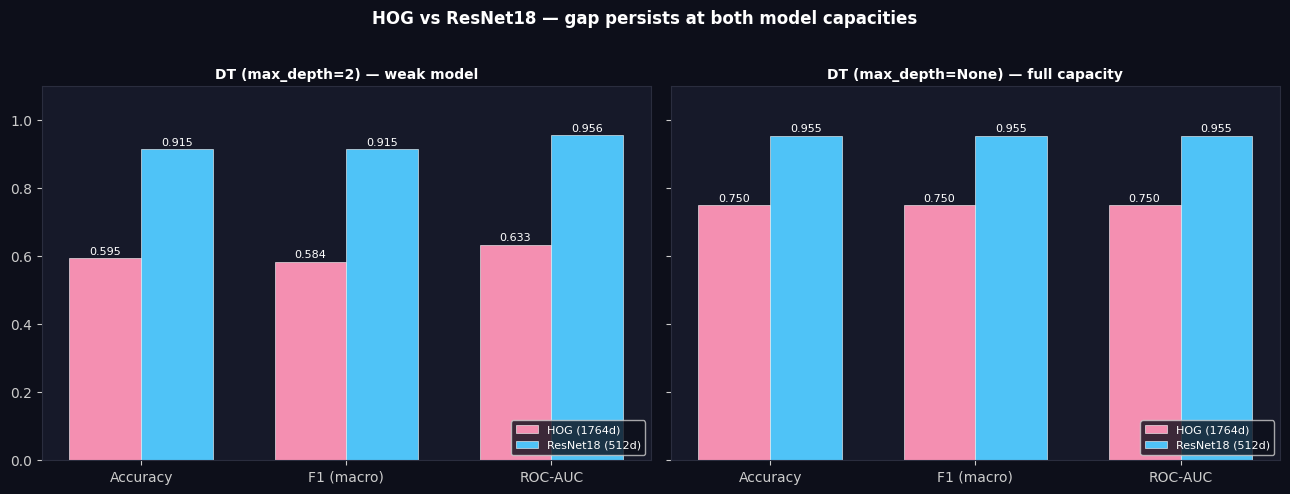

[PLOT] Saved → /content/drive/MyDrive/appliedAI/outputs_supervised/hog_vs_resnet.png


In [7]:
# ── Step 1-B — HOG baseline: extraction + DT comparison, fully checkpointed ──
from skimage.feature import hog
from skimage.color import rgb2gray

HOG_IMG_SIZE = 224                 # SAME input as ResNet → isolates the 'feature' variable
                                   # With pixels_per_cell=(28,28): 8x8 cells, 1764 final dim
HOG_PARAMS   = dict(
    orientations=9,
    pixels_per_cell=(28, 28),     # 224/28 = 8 cells per side (same grid as old 128/16)
    cells_per_block=(2, 2),
    block_norm='L2-Hys',
    transform_sqrt=True,
    feature_vector=True,
)

def extract_hog_features(dataset, ckpt_path=None):
    """
    Extract HOG descriptors from a labelled dataset.
    Same checkpoint pattern as extract_resnet_features:
    if ckpt_path exists, load from disk; otherwise compute, save and return.
    """
    if ckpt_path and ckpt_path.exists():
        print(f'  Loading from checkpoint: {ckpt_path.name}')
        X, y = _load_npz(ckpt_path)
        print(f'    shape={X.shape}')
        return X, y

    hog_transform = transforms.Compose([
        transforms.Resize((HOG_IMG_SIZE, HOG_IMG_SIZE)),
        transforms.Grayscale(num_output_channels=1),
    ])
    dataset.transform = hog_transform

    feats_list, labels_list = [], []
    t0 = time.time()
    for i in range(len(dataset)):
        img, label = dataset[i]
        arr = np.asarray(img, dtype=np.float32) / 255.0
        feats_list.append(hog(arr, **HOG_PARAMS))
        labels_list.append(label)
        if (i + 1) % 1000 == 0:
            print(f'    {i+1}/{len(dataset)}  elapsed={time.time()-t0:.0f}s')

    dataset.transform = None
    X = np.vstack(feats_list).astype(np.float32)
    y = np.asarray(labels_list, dtype=np.int64)
    print(f'    shape={X.shape}  total_time={time.time()-t0:.0f}s')

    if ckpt_path:
        _save_npz(ckpt_path, X, y)
    return X, y


print('[STEP 1-B] Extracting HOG features...')
print('  Training set:')
X_hog_train, y_hog_train = extract_hog_features(train_dataset, CKPT_HOG_TRAIN)
print('  Validation set:')
X_hog_val,   y_hog_val   = extract_hog_features(val_dataset,   CKPT_HOG_VAL)

assert np.array_equal(y_hog_train, y_train), 'HOG train labels diverge from ResNet labels'
assert np.array_equal(y_hog_val,   y_val),   'HOG val labels diverge from ResNet labels'


# ─────────────────────────────────────────────────────────────────────────────
# Helper: fit (or load) a DT and evaluate on the val set
# ─────────────────────────────────────────────────────────────────────────────
def train_or_load_dt(X_tr, y_tr, X_va, y_va, max_depth, ckpt_path, tag):
    """Train DT on 100% of TRAIN (with its own scaler), eval on VAL.
    Cache to ckpt_path if provided. Returns metrics dict."""
    if ckpt_path is not None and ckpt_path.exists():
        print(f'  [{tag}] Loading from checkpoint: {ckpt_path.name}')
        payload = joblib.load(ckpt_path)
        clf, scaler = payload['clf'], payload['scaler']
    else:
        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)              # fit on TRAIN only
        clf = DecisionTreeClassifier(
            max_depth=max_depth, criterion='gini', random_state=RANDOM_STATE
        )
        # *** Trained on 100% of TRAIN features (no fold held back). ***
        t0 = time.time()
        clf.fit(X_tr_sc, y_tr)
        print(f'  [{tag}] Trained in {time.time()-t0:.1f}s  (effective depth={clf.get_depth()}, leaves={clf.get_n_leaves()})')
        if ckpt_path is not None:
            joblib.dump({'clf': clf, 'scaler': scaler}, ckpt_path)
            print(f'  [CKPT] Saved trained DT → {ckpt_path}')

    X_va_sc = scaler.transform(X_va)
    y_pred  = clf.predict(X_va_sc)
    y_proba = clf.predict_proba(X_va_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_va, y_proba)
    return dict(
        acc=accuracy_score(y_va, y_pred),
        f1 =f1_score(y_va, y_pred, average='macro'),
        auc=auc(fpr, tpr),
        depth=clf.get_depth(),
        leaves=clf.get_n_leaves(),
    )


# ── Train 4 models: {HOG, ResNet} x {DT depth=2, DT depth=None} ──────────────
print('\n[STEP 1-B] Training comparison models...')

# (1) DT(depth=2) on HOG  -- low capacity, weakest baseline
print('\n  -- DT(max_depth=2) on HOG --')
m_hog_d2  = train_or_load_dt(X_hog_train, y_hog_train, X_hog_val, y_hog_val,
                             max_depth=2, ckpt_path=CKPT_HOG_DT,
                             tag='HOG d=2')

# (2) DT(depth=None) on HOG  -- full capacity, can exploit all 1764 dims
print('\n  -- DT(max_depth=None) on HOG --')
m_hog_inf = train_or_load_dt(X_hog_train, y_hog_train, X_hog_val, y_hog_val,
                             max_depth=None, ckpt_path=CKPT_HOG_DT_DEEP,
                             tag='HOG d=inf')

# (3) DT(depth=2) on ResNet  -- low capacity (matches Step 2 DT_depth2_gini)
print('\n  -- DT(max_depth=2) on ResNet --')
m_res_d2  = train_or_load_dt(X_resnet_train, y_train, X_resnet_val, y_val,
                             max_depth=2, ckpt_path=None,
                             tag='ResNet d=2')

# (4) DT(depth=None) on ResNet  -- full capacity
print('\n  -- DT(max_depth=None) on ResNet --')
m_res_inf = train_or_load_dt(X_resnet_train, y_train, X_resnet_val, y_val,
                             max_depth=None, ckpt_path=None,
                             tag='ResNet d=inf')


# ── Comparison table: 2 models x 2 feature spaces ───────────────────────────
print('\n' + '='*78)
print('  Feature comparison — same model, two capacity levels')
print('='*78)
print(f'{"Model":<22}{"Feature":<24}{"dim":>6}{"Acc":>10}{"F1":>10}{"AUC":>10}')
print('-'*78)
print(f'{"DT (max_depth=2)":<22}{"HOG (handcrafted)":<24}{X_hog_train.shape[1]:>6}'
      f'{m_hog_d2["acc"]:>10.4f}{m_hog_d2["f1"]:>10.4f}{m_hog_d2["auc"]:>10.4f}')
print(f'{"DT (max_depth=2)":<22}{"ResNet18 (pretrained)":<24}{X_resnet_train.shape[1]:>6}'
      f'{m_res_d2["acc"]:>10.4f}{m_res_d2["f1"]:>10.4f}{m_res_d2["auc"]:>10.4f}')
print(f'{"Δ":<22}{"(ResNet − HOG)":<24}{"":>6}'
      f'{m_res_d2["acc"]-m_hog_d2["acc"]:>+10.4f}'
      f'{m_res_d2["f1"]-m_hog_d2["f1"]:>+10.4f}'
      f'{m_res_d2["auc"]-m_hog_d2["auc"]:>+10.4f}')
print('-'*78)
print(f'{"DT (max_depth=None)":<22}{"HOG (handcrafted)":<24}{X_hog_train.shape[1]:>6}'
      f'{m_hog_inf["acc"]:>10.4f}{m_hog_inf["f1"]:>10.4f}{m_hog_inf["auc"]:>10.4f}')
print(f'{"DT (max_depth=None)":<22}{"ResNet18 (pretrained)":<24}{X_resnet_train.shape[1]:>6}'
      f'{m_res_inf["acc"]:>10.4f}{m_res_inf["f1"]:>10.4f}{m_res_inf["auc"]:>10.4f}')
print(f'{"Δ":<22}{"(ResNet − HOG)":<24}{"":>6}'
      f'{m_res_inf["acc"]-m_hog_inf["acc"]:>+10.4f}'
      f'{m_res_inf["f1"]-m_hog_inf["f1"]:>+10.4f}'
      f'{m_res_inf["auc"]-m_hog_inf["auc"]:>+10.4f}')
print('='*78)


# ── Comparison plot: grouped bars, 2 panels (one per model) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
fig.patch.set_facecolor('#0d0f1a')
metric_names = ['Accuracy', 'F1 (macro)', 'ROC-AUC']
x = np.arange(len(metric_names)); w = 0.35

for ax, (title, m_hog, m_res) in zip(axes, [
    ('DT (max_depth=2) — weak model',     m_hog_d2,  m_res_d2),
    ('DT (max_depth=None) — full capacity', m_hog_inf, m_res_inf),
]):
    ax.set_facecolor('#161929'); ax.tick_params(colors='#ccc')
    for sp in ax.spines.values(): sp.set_color('#2a2d3e')
    hog_vals = [m_hog['acc'], m_hog['f1'], m_hog['auc']]
    res_vals = [m_res['acc'], m_res['f1'], m_res['auc']]
    b1 = ax.bar(x - w/2, hog_vals, w, label=f'HOG ({X_hog_train.shape[1]}d)',
                color='#F48FB1', edgecolor='white', linewidth=0.4)
    b2 = ax.bar(x + w/2, res_vals, w, label=f'ResNet18 ({X_resnet_train.shape[1]}d)',
                color='#4FC3F7', edgecolor='white', linewidth=0.4)
    for bars, vals in [(b1, hog_vals), (b2, res_vals)]:
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, v+0.012, f'{v:.3f}',
                    ha='center', color='white', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(metric_names, color='#ccc')
    ax.set_ylim(0, 1.1)
    ax.set_title(title, color='white', fontsize=10, fontweight='bold')
    ax.legend(facecolor='#0d0f1a', labelcolor='white', fontsize=8, loc='lower right')

fig.suptitle('HOG vs ResNet18 — gap persists at both model capacities',
             color='white', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
out_cmp = OUTPUT_DIR / 'hog_vs_resnet.png'
plt.savefig(out_cmp, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'[PLOT] Saved → {out_cmp}')


## Step 2 — Modeling: Decision Tree baselines + Gradient Boosting (× 5)

**7 configurations total:**
- **2 plain DT baselines** (no boosting) — establish the performance floor and quantify the gain from Gradient Boosting
- **5 Gradient Boosting + DT variants** — varying `n_estimators`, `learning_rate`, `max_depth`, `subsample` (stochastic GB), and `min_samples_leaf`

Each configuration is trained on the training set, cross-validated (5-fold), and evaluated on the validation set.

**Why Gradient Boosting:** GB (Friedman 1999) is the generalized boosting framework — each tree fits the gradient of a differentiable loss function (here, log-loss for binary classification). AdaBoost is the special case where the loss is exponential. GB allows direct control of regularization via `learning_rate`, `subsample`, and `min_samples_leaf`, which is the basis of the hyperparameter tuning below.

In [11]:
# 7 configurations: 2 plain DT baselines + 5 Gradient Boosting + DT variants.
# Plain DT baselines allow direct comparison of boosting vs a single tree.
# GB configs vary FIVE hyperparameters: n_estimators, learning_rate,
# max_depth, subsample (stochastic GB), and min_samples_leaf.
BOOSTING_CONFIGS = {
    # ── Baselines: plain Decision Tree (no boosting) ──────────────────────────
    # Used to quantify the gain from Gradient Boosting over a single tree.

    # Baseline 1: single stump — minimum capacity reference
    'DT_depth1_gini': DecisionTreeClassifier(
        max_depth=1, criterion='gini', random_state=RANDOM_STATE),

    # Baseline 2: depth-2 tree — slightly stronger reference
    'DT_depth2_gini': DecisionTreeClassifier(
        max_depth=2, criterion='gini', random_state=RANDOM_STATE),

    # ── Gradient Boosting + DT (ensemble with gradient-based boosting) ────────

    # n=10 + subsample=0.7 + depth=3
    'GB_n10_lr01_d2_sub07': GradientBoostingClassifier(
        n_estimators=10, learning_rate=0.1, max_depth=2,
        subsample=0.7, min_samples_leaf=1,
        random_state=RANDOM_STATE),

    # slow learner
    'GB_n50_lr005_d3_sub07': GradientBoostingClassifier(
        n_estimators=50, learning_rate=0.05, max_depth=3,
        subsample=0.7, min_samples_leaf=1,
        random_state=RANDOM_STATE),

    # stochastic agressive
    'GB_n100_lr01_d2_sub05': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=2,
        subsample=0.5, min_samples_leaf=1,
        random_state=RANDOM_STATE),

    # high lr + regularization
    'GB_n50_lr05_d3_leaf5': GradientBoostingClassifier(
        n_estimators=50, learning_rate=0.5, max_depth=3,
        subsample=1, min_samples_leaf=5,
        random_state=RANDOM_STATE),

    # balaced
    'GB_n75_lr01_d4_sub07_leaf3': GradientBoostingClassifier(
        n_estimators=75, learning_rate=0.1, max_depth=4,
        subsample=0.7, min_samples_leaf=3,
        random_state=RANDOM_STATE),
}


In [13]:
def run_pipeline(X_train: np.ndarray, y_train: np.ndarray,
                 X_val:   np.ndarray, y_val:   np.ndarray,
                 label: str, ckpt_path=None, n_splits: int = 5) -> tuple:
    """
    Scale -> 5-fold CV on train -> FINAL FIT on 100% of train -> evaluate on val.
    Returns (results, scaler).

    Train/Val split guarantee:
    - X_train / y_train come EXCLUSIVELY from TRAIN_DIR (`training/`)        (10000 imgs)
    - X_val   / y_val   come EXCLUSIVELY from VAL_DIR   (`museum_validation/`) (200 imgs)
    - The two folders are physically separated on disk; no file appears in both.
    - The final classifier reported in the metrics (acc / f1 / AUC / CM) is
      trained on 100% of the train set and evaluated on the held-out val set.
    """
    results = {}
    scaler  = None

    # Load existing checkpoint (may be partial - only some configs saved)
    if ckpt_path and ckpt_path.exists():
        payload = joblib.load(ckpt_path)
        results = payload['results']
        scaler  = payload['scaler']
        print(f'\n[STEP 2] Checkpoint loaded: {ckpt_path.name}')
        for name, r in results.items():
            print(f'  [LOADED] {name}  Acc={r["acc"]:.4f}  F1={r["f1"]:.4f}  AUC={r["roc_auc"]:.4f}')

    missing = {name: clf for name, clf in BOOSTING_CONFIGS.items()
               if name not in results}

    if not missing:
        print('  [CKPT] All configs already trained - nothing to do.')
        return results, scaler

    # StandardScaler fitted ONLY on training data - val is transformed with the
    # same statistics. This prevents leakage of validation distribution into
    # the preprocessing step.
    # Note: Decision Trees are scale-invariant - normalization does not affect
    # DT or GB+DT numerically. Kept for pipeline consistency.
    if scaler is None:
        scaler     = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)   # <-- fit on TRAIN only
    else:
        X_train_sc = scaler.transform(X_train)
    X_val_sc = scaler.transform(X_val)               # <-- val transformed, never fitted

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    print(f'\n{"-"*64}')
    print(f'  {label}')
    print(f'  features={X_train.shape[1]}  train={len(X_train)}  val={len(X_val)}')
    print(f'  Training {len(missing)} new config(s): {list(missing.keys())}')
    print(f'{"-"*64}')

    for name, clf in missing.items():
        print(f'  [MODEL] {name}')

        # =====================================================================
        # STEP A - Internal model assessment via 5-fold Stratified CV.
        # cross_val_score creates INTERNAL train/val folds INSIDE the training
        # set: each fold trains on 80% of TRAIN and tests on 20% of TRAIN.
        # NO image from museum_validation/ is ever used here.
        # The classifier `clf` is cloned inside cross_val_score - it is NOT
        # the same fitted object that produces the final metrics below.
        # =====================================================================
        t0 = time.time()
        cv = cross_val_score(clf, X_train_sc, y_train, cv=skf,
                             scoring='f1_macro', n_jobs=-1)

        # =====================================================================
        # STEP B - *** FINAL FIT ON 100% OF TRAIN ***
        # Timer starts here — after CV — so `time` measures only the single
        # final fit, not the 5 internal CV folds.
        # =====================================================================

        clf.fit(X_train_sc, y_train)        # <<< trained on 100% of TRAIN

        # =====================================================================
        # STEP C - Predict on the held-out validation set.
        # All metrics below (acc, f1, precision, recall, AUC, CM) are computed
        # against y_val, which the model has never seen.
        # =====================================================================
        y_pred  = clf.predict(X_val_sc)
        y_proba = clf.predict_proba(X_val_sc)[:, 1]

        acc         = accuracy_score(y_val, y_pred)
        f1          = f1_score(y_val, y_pred, average="macro")
        fpr, tpr, _ = roc_curve(y_val, y_proba)
        roc_auc     = auc(fpr, tpr)
        elapsed     = time.time() - t0

        results[name] = dict(
            clf=clf, scaler=scaler,
            acc=acc, f1=f1, roc_auc=roc_auc,
            cv_f1=cv, fpr=fpr, tpr=tpr,
            cm=confusion_matrix(y_val, y_pred),
            y_pred=y_pred, y_proba=y_proba, y_test=y_val,
            time=elapsed,
            report=classification_report(y_val, y_pred, target_names=CLASSES),
        )
        print(f'    Acc={acc:.4f}  F1={f1:.4f}  AUC={roc_auc:.4f}  '
              f'CV_F1={cv.mean():.4f}+/-{cv.std():.4f}  t={elapsed:.1f}s')

    if ckpt_path:
        joblib.dump({'results': results, 'scaler': scaler}, ckpt_path)
        print(f'  [CKPT] Saved -> {ckpt_path}')
    return results, scaler

In [14]:
# ── PIPELINE A ─ Run (or load from checkpoint) ──────────────────────────────
print('=' * 64)
print('  Running Pipeline A — ResNet18')
print('=' * 64)
# 5-fold CV  |  512-d features  |  saves to CKPT_MODELS_R
res_r, sc_r = run_pipeline(
    X_resnet_train, y_train, X_resnet_val, y_val,
    'Pipeline A - ResNet18', CKPT_MODELS_R, n_splits=5
)
print('\n[Pipeline A done — checkpoint saved. You can stop here and resume later.]')


  Running Pipeline A — ResNet18

[STEP 2] Checkpoint loaded: sup_models_resnet_gb.joblib
  [LOADED] DT_depth1_gini  Acc=0.9100  F1=0.9098  AUC=0.9100
  [LOADED] DT_depth2_gini  Acc=0.9150  F1=0.9147  AUC=0.9563
  [LOADED] GB_n50_lr01_d2_sub07  Acc=0.9750  F1=0.9750  AUC=0.9948
  [LOADED] GB_n50_lr005_d3_sub07  Acc=0.9750  F1=0.9750  AUC=0.9924
  [LOADED] GB_n100_lr01_d2_sub05  Acc=0.9600  F1=0.9600  AUC=0.9948
  [LOADED] GB_n50_lr03_d3_leaf5  Acc=0.9750  F1=0.9750  AUC=0.9961
  [LOADED] GB_n75_lr01_d3_sub07_leaf3  Acc=0.9700  F1=0.9700  AUC=0.9964

----------------------------------------------------------------
  Pipeline A - ResNet18
  features=512  train=10000  val=200
  Training 3 new config(s): ['GB_n10_lr01_d2_sub07', 'GB_n50_lr05_d3_leaf5', 'GB_n75_lr01_d4_sub07_leaf3']
----------------------------------------------------------------
  [MODEL] GB_n10_lr01_d2_sub07
    Acc=0.9550  F1=0.9549  AUC=0.9882  CV_F1=0.9263+/-0.0016  t=82.4s
  [MODEL] GB_n50_lr05_d3_leaf5
    Acc=0.9750 

## Gradient Boosting Learning Curves

Plots validation F1 as a function of `n_estimators` for each Gradient Boosting configuration.
Uses `staged_predict` on already-trained models — **no retraining required**.
Plain DT baselines appear as horizontal reference lines to show the boosting gain.

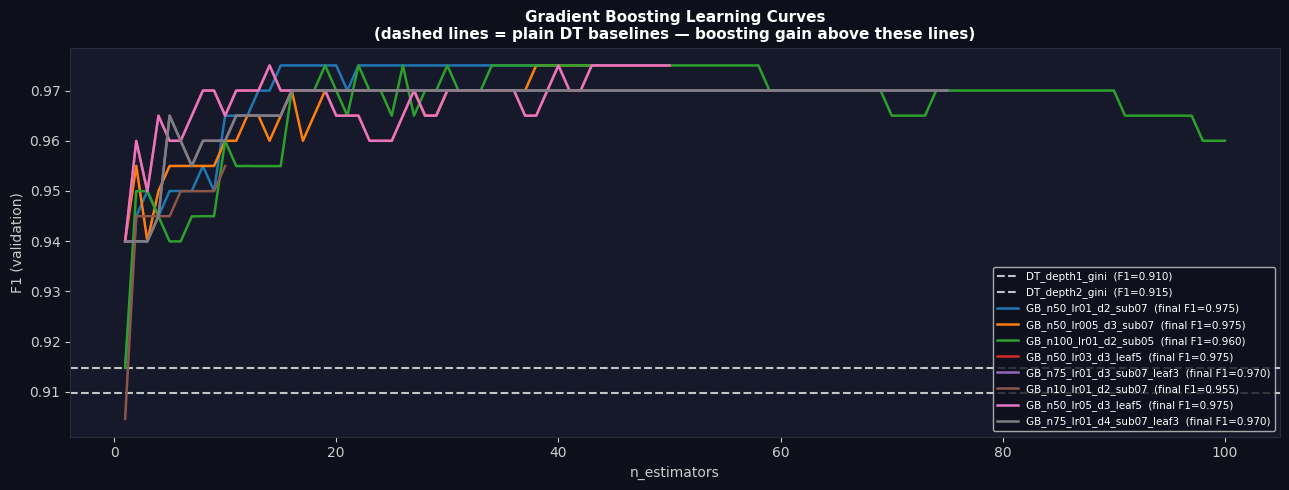

[LEARNING CURVES] Saved → /content/drive/MyDrive/appliedAI/outputs_supervised/learning_curves.png


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score


# ── Gradient Boosting learning curves (uses already-trained models) ──────────

def plot_learning_curves(results, X_val_sc, y_val):
    """
    Plot validation F1 as a function of n_estimators for each GB config.
    Uses staged_predict — iterates over already-fitted estimators, no retraining.
    Plain DT baselines are shown as horizontal dashed reference lines.
    """
    fig, ax = plt.subplots(figsize=(13, 5))
    fig.patch.set_facecolor('#0d0f1a')
    ax.set_facecolor('#161929')
    ax.tick_params(colors='#ccc')
    ax.xaxis.label.set_color('#ccc')
    ax.yaxis.label.set_color('#ccc')
    for sp in ax.spines.values():
        sp.set_color('#2a2d3e')

    # Count the number of Gradient Boosting models to determine palette size
    num_gb_models = sum(1 for r_item in results.values()
                        if isinstance(r_item['clf'], GradientBoostingClassifier))
    gb_palette = sns.color_palette('tab10', max(num_gb_models, 1)) # Ensure at least 1 for proper palette creation
    gb_idx     = 0

    for name, r in results.items():
        clf = r['clf']

        # Plain DT: horizontal dashed line (staged_predict not available)
        if isinstance(clf, DecisionTreeClassifier):
            ax.axhline(r['f1'], linestyle='--', linewidth=1.5, alpha=0.75,
                       label=f'{name}  (F1={r["f1"]:.3f})', color='white')
            continue

        # GB: F1 at each boosting stage — no retraining, reads estimators_ list
        staged_f1 = [f1_score(y_val, y_p, average="macro")
                     for y_p in clf.staged_predict(X_val_sc)]
        ax.plot(range(1, len(staged_f1) + 1), staged_f1,
                color=gb_palette[gb_idx], lw=1.8,
                label=f'{name}  (final F1={r["f1"]:.3f})')
        gb_idx += 1

    ax.set_xlabel('n_estimators')
    ax.set_ylabel('F1 (validation)')
    ax.set_title('Gradient Boosting Learning Curves\n'
                 '(dashed lines = plain DT baselines — boosting gain above these lines)',
                 color='white', fontsize=11, fontweight='bold')
    ax.legend(fontsize=7.5, facecolor='#0d0f1a', labelcolor='white',
              loc='lower right')
    plt.tight_layout()
    out_lc = OUTPUT_DIR / 'learning_curves.png'
    plt.savefig(out_lc, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f'[LEARNING CURVES] Saved → {out_lc}')

# Scale val features once using the fitted scaler from the pipeline
X_val_sc_lc = sc_r.transform(X_resnet_val)
plot_learning_curves(res_r, X_val_sc_lc, y_val)

In [18]:
# ── COMBINE RESULTS ────────────────────────────────────────────────────────
all_results = {'resnet': res_r}
scalers     = {'resnet': sc_r}
print('Results ready — generating report.')
for mn, r in all_results['resnet'].items():
    print(f'  {mn:35s}  Acc={r["acc"]:.4f}  F1={r["f1"]:.4f}  AUC={r["roc_auc"]:.4f}')


Results ready — generating report.
  DT_depth1_gini                       Acc=0.9100  F1=0.9098  AUC=0.9100
  DT_depth2_gini                       Acc=0.9150  F1=0.9147  AUC=0.9563
  GB_n50_lr01_d2_sub07                 Acc=0.9750  F1=0.9750  AUC=0.9948
  GB_n50_lr005_d3_sub07                Acc=0.9750  F1=0.9750  AUC=0.9924
  GB_n100_lr01_d2_sub05                Acc=0.9600  F1=0.9600  AUC=0.9948
  GB_n50_lr03_d3_leaf5                 Acc=0.9750  F1=0.9750  AUC=0.9961
  GB_n75_lr01_d3_sub07_leaf3           Acc=0.9700  F1=0.9700  AUC=0.9964
  GB_n10_lr01_d2_sub07                 Acc=0.9550  F1=0.9549  AUC=0.9882
  GB_n50_lr05_d3_leaf5                 Acc=0.9750  F1=0.9750  AUC=0.9961
  GB_n75_lr01_d4_sub07_leaf3           Acc=0.9700  F1=0.9700  AUC=0.9964


## Step 3 — Report

Generates a comprehensive figure with grouped bar charts, ROC curves, confusion matrices,
CV F1 heatmap, ΔF1 comparison, and a full summary table.

In [19]:
PIPE_META = {
    'resnet': {'label': 'Pipeline A — ResNet18 (512-d)', 'color': '#4FC3F7'},
}

def build_report(all_results: dict):
    model_names = list(BOOSTING_CONFIGS.keys())
    n           = len(model_names)
    palette     = sns.color_palette('tab10', n)

    fig = plt.figure(figsize=(20, 34))
    fig.patch.set_facecolor('#0d0f1a')
    gs  = gridspec.GridSpec(5, 3, figure=fig, hspace=0.62, wspace=0.40)
    tkw  = dict(color='white', fontsize=10, fontweight='bold', pad=8)
    axbg = '#161929'
    color = PIPE_META['resnet']['color']

    def sa(ax):
        ax.set_facecolor(axbg); ax.tick_params(colors='#ccc')
        ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')
        for sp in ax.spines.values(): sp.set_color('#2a2d3e')

    xlbls = [m.replace('_', '\n') for m in model_names]
    x, w  = np.arange(n), 0.6

    # Row 0: Accuracy / F1 / AUC bars
    for col, (mkey, mtitle) in enumerate([('acc','Accuracy'),('f1','F1 Score'),('roc_auc','ROC-AUC')]):
        ax = fig.add_subplot(gs[0, col]); sa(ax)
        vals = [all_results['resnet'][m][mkey] for m in model_names]
        bars = ax.bar(x, vals, w, color=color, edgecolor='white', linewidth=0.4, alpha=0.88)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, v+0.012,
                    f'{v:.2f}', ha='center', color='white', fontsize=6.5)
        ax.set_xticks(x); ax.set_xticklabels(xlbls, color='#ccc', fontsize=6.5)
        ax.set_ylim(0, 1.15); ax.set_title(mtitle, **tkw)

    # Row 1: ROC curves (spans 2 cols) + CV F1 heatmap
    ax_roc = fig.add_subplot(gs[1, 0:2]); sa(ax_roc)
    ax_roc.plot([0,1],[0,1],'w--',lw=1,alpha=0.35,label='Random')
    for i, mn in enumerate(model_names):
        r = all_results['resnet'][mn]
        ax_roc.plot(r['fpr'], r['tpr'], color=palette[i], lw=1.8,
                label=f'{mn} ({r["roc_auc"]:.3f})')
    ax_roc.set_xlabel('False Positive Rate'); ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title('ROC Curves — Pipeline A: ResNet18', **tkw)
    ax_roc.legend(fontsize=5.5, facecolor='#0d0f1a', labelcolor='white')

    ax_heat = fig.add_subplot(gs[1, 2]); sa(ax_heat)
    heat = np.array([[all_results['resnet'][mn]['cv_f1'].mean() for mn in model_names]])
    im = ax_heat.imshow(heat, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    ax_heat.set_xticks(range(n)); ax_heat.set_xticklabels(xlbls, color='#ccc', fontsize=6.5)
    ax_heat.set_yticks([0]); ax_heat.set_yticklabels(['ResNet18'], color='#ccc', fontsize=8)
    ax_heat.set_title('CV F1 Mean Heatmap\n(5-fold on train, darker = better)', **tkw)
    for j in range(n):
        ax_heat.text(j, 0, f'{heat[0,j]:.3f}', ha='center', va='center',
                     color='black', fontsize=9, fontweight='bold')
    plt.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04)

    # Row 2: Best confusion matrix + CV F1 boxplot
    best_mn = max(model_names, key=lambda m: all_results['resnet'][m]['f1'])
    ax_cm = fig.add_subplot(gs[2, 0]); sa(ax_cm)
    ConfusionMatrixDisplay(all_results['resnet'][best_mn]['cm'],
                           display_labels=CLASSES).plot(ax=ax_cm, colorbar=False, cmap='Blues')
    ax_cm.set_title(f'Best CM — ResNet18\n{best_mn}', **tkw)
    ax_cm.xaxis.label.set_color('#ccc'); ax_cm.yaxis.label.set_color('#ccc')

    ax_box = fig.add_subplot(gs[2, 1:]); sa(ax_box)
    cv_data = [all_results['resnet'][m]['cv_f1'] for m in model_names]
    bp = ax_box.boxplot(cv_data, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2))
    for patch, c in zip(bp['boxes'], palette):
        patch.set_facecolor(c); patch.set_alpha(0.75)
    ax_box.set_xticks(range(1, n+1)); ax_box.set_xticklabels(xlbls, color='#ccc', fontsize=6.5)
    ax_box.set_ylim(0, 1.1)
    ax_box.set_title('CV F1 Distribution — Pipeline A: ResNet18', **tkw)

    # Row 3: Per-class Precision & Recall
    class_colors = ['#4FC3F7', '#F48FB1']
    w2 = 0.35

    ax_prec = fig.add_subplot(gs[3, 0:2]); sa(ax_prec)
    ax_rec  = fig.add_subplot(gs[3, 2]);   sa(ax_rec)

    for ci, cls_name in enumerate(CLASSES):
        prec_vals = [precision_score(all_results['resnet'][m]['y_test'],
                                     all_results['resnet'][m]['y_pred'],
                                     average=None)[ci] for m in model_names]
        rec_vals  = [recall_score(all_results['resnet'][m]['y_test'],
                                   all_results['resnet'][m]['y_pred'],
                                   average=None)[ci] for m in model_names]
        offset = (ci - 0.5) * w2
        bars_p = ax_prec.bar(x + offset, prec_vals, w2, label=cls_name,
                             color=class_colors[ci], edgecolor='white', linewidth=0.4, alpha=0.88)
        bars_r = ax_rec.bar(x + offset, rec_vals, w2, label=cls_name,
                            color=class_colors[ci], edgecolor='white', linewidth=0.4, alpha=0.88)
        for bar, v in zip(bars_p, prec_vals):
            ax_prec.text(bar.get_x()+bar.get_width()/2, v+0.012,
                         f'{v:.2f}', ha='center', color='white', fontsize=6)
        for bar, v in zip(bars_r, rec_vals):
            ax_rec.text(bar.get_x()+bar.get_width()/2, v+0.012,
                        f'{v:.2f}', ha='center', color='white', fontsize=6)

    ax_prec.set_xticks(x); ax_prec.set_xticklabels(xlbls, color='#ccc', fontsize=6.5)
    ax_prec.set_ylim(0, 1.25)
    ax_prec.set_title('Precision per Class — Pipeline A: ResNet18', **tkw)
    ax_prec.legend(fontsize=7, facecolor='#0d0f1a', labelcolor='white')

    ax_rec.set_xticks(x); ax_rec.set_xticklabels(xlbls, color='#ccc', fontsize=6.5)
    ax_rec.set_ylim(0, 1.25)
    ax_rec.set_title('Recall per Class\n— Pipeline A: ResNet18', **tkw)
    ax_rec.legend(fontsize=7, facecolor='#0d0f1a', labelcolor='white')

    # Row 4: Training time + summary table
    ax_time = fig.add_subplot(gs[4, 0]); sa(ax_time)
    times = [all_results['resnet'][m]['time'] for m in model_names]
    ax_time.bar(x, times, w, color=color, edgecolor='white', linewidth=0.4, alpha=0.88)
    ax_time.set_xticks(x); ax_time.set_xticklabels(xlbls, color='#ccc', fontsize=6.5)
    ax_time.set_ylabel('seconds'); ax_time.set_title('Training Time (s)', **tkw)

    ax_tbl = fig.add_subplot(gs[4, 1:]); sa(ax_tbl); ax_tbl.axis('off')
    col_labels = ['Model','Accuracy','F1','ROC-AUC','CV F1 μ','CV F1 σ','Time (s)']
    rows = []
    for mn in model_names:
        r = all_results['resnet'][mn]
        rows.append([
            mn, f'{r["acc"]:.4f}', f'{r["f1"]:.4f}', f'{r["roc_auc"]:.4f}',
            f'{r["cv_f1"].mean():.4f}', f'{r["cv_f1"].std():.4f}', f'{r["time"]:.1f}',
        ])
    tbl = ax_tbl.table(cellText=rows, colLabels=col_labels, loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.90)
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor('#2a2d3e')
        if row == 0:
            cell.set_facecolor('#1e2235'); cell.set_text_props(color='white', fontweight='bold')
        else:
            cell.set_facecolor('#0d1828' if row%2 else '#091220')
            cell.set_text_props(color='#B3E5FC')
    ax_tbl.set_title('Results Summary — Pipeline A: ResNet18', **tkw)

    fig.text(0.5, 0.987, 'Museum Classifier — Supervised Decision Tree + Gradient Boosting',
             ha='center', va='top', color='white', fontsize=17, fontweight='bold')
    fig.text(0.5, 0.974,
             'Step 3 Report  |  Pipeline A: ResNet18 (512-d)',
             ha='center', va='top', color='#aaa', fontsize=10)

    out = OUTPUT_DIR / 'report_supervised.png'
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f'\n[REPORT] Saved → {out}')
    return out

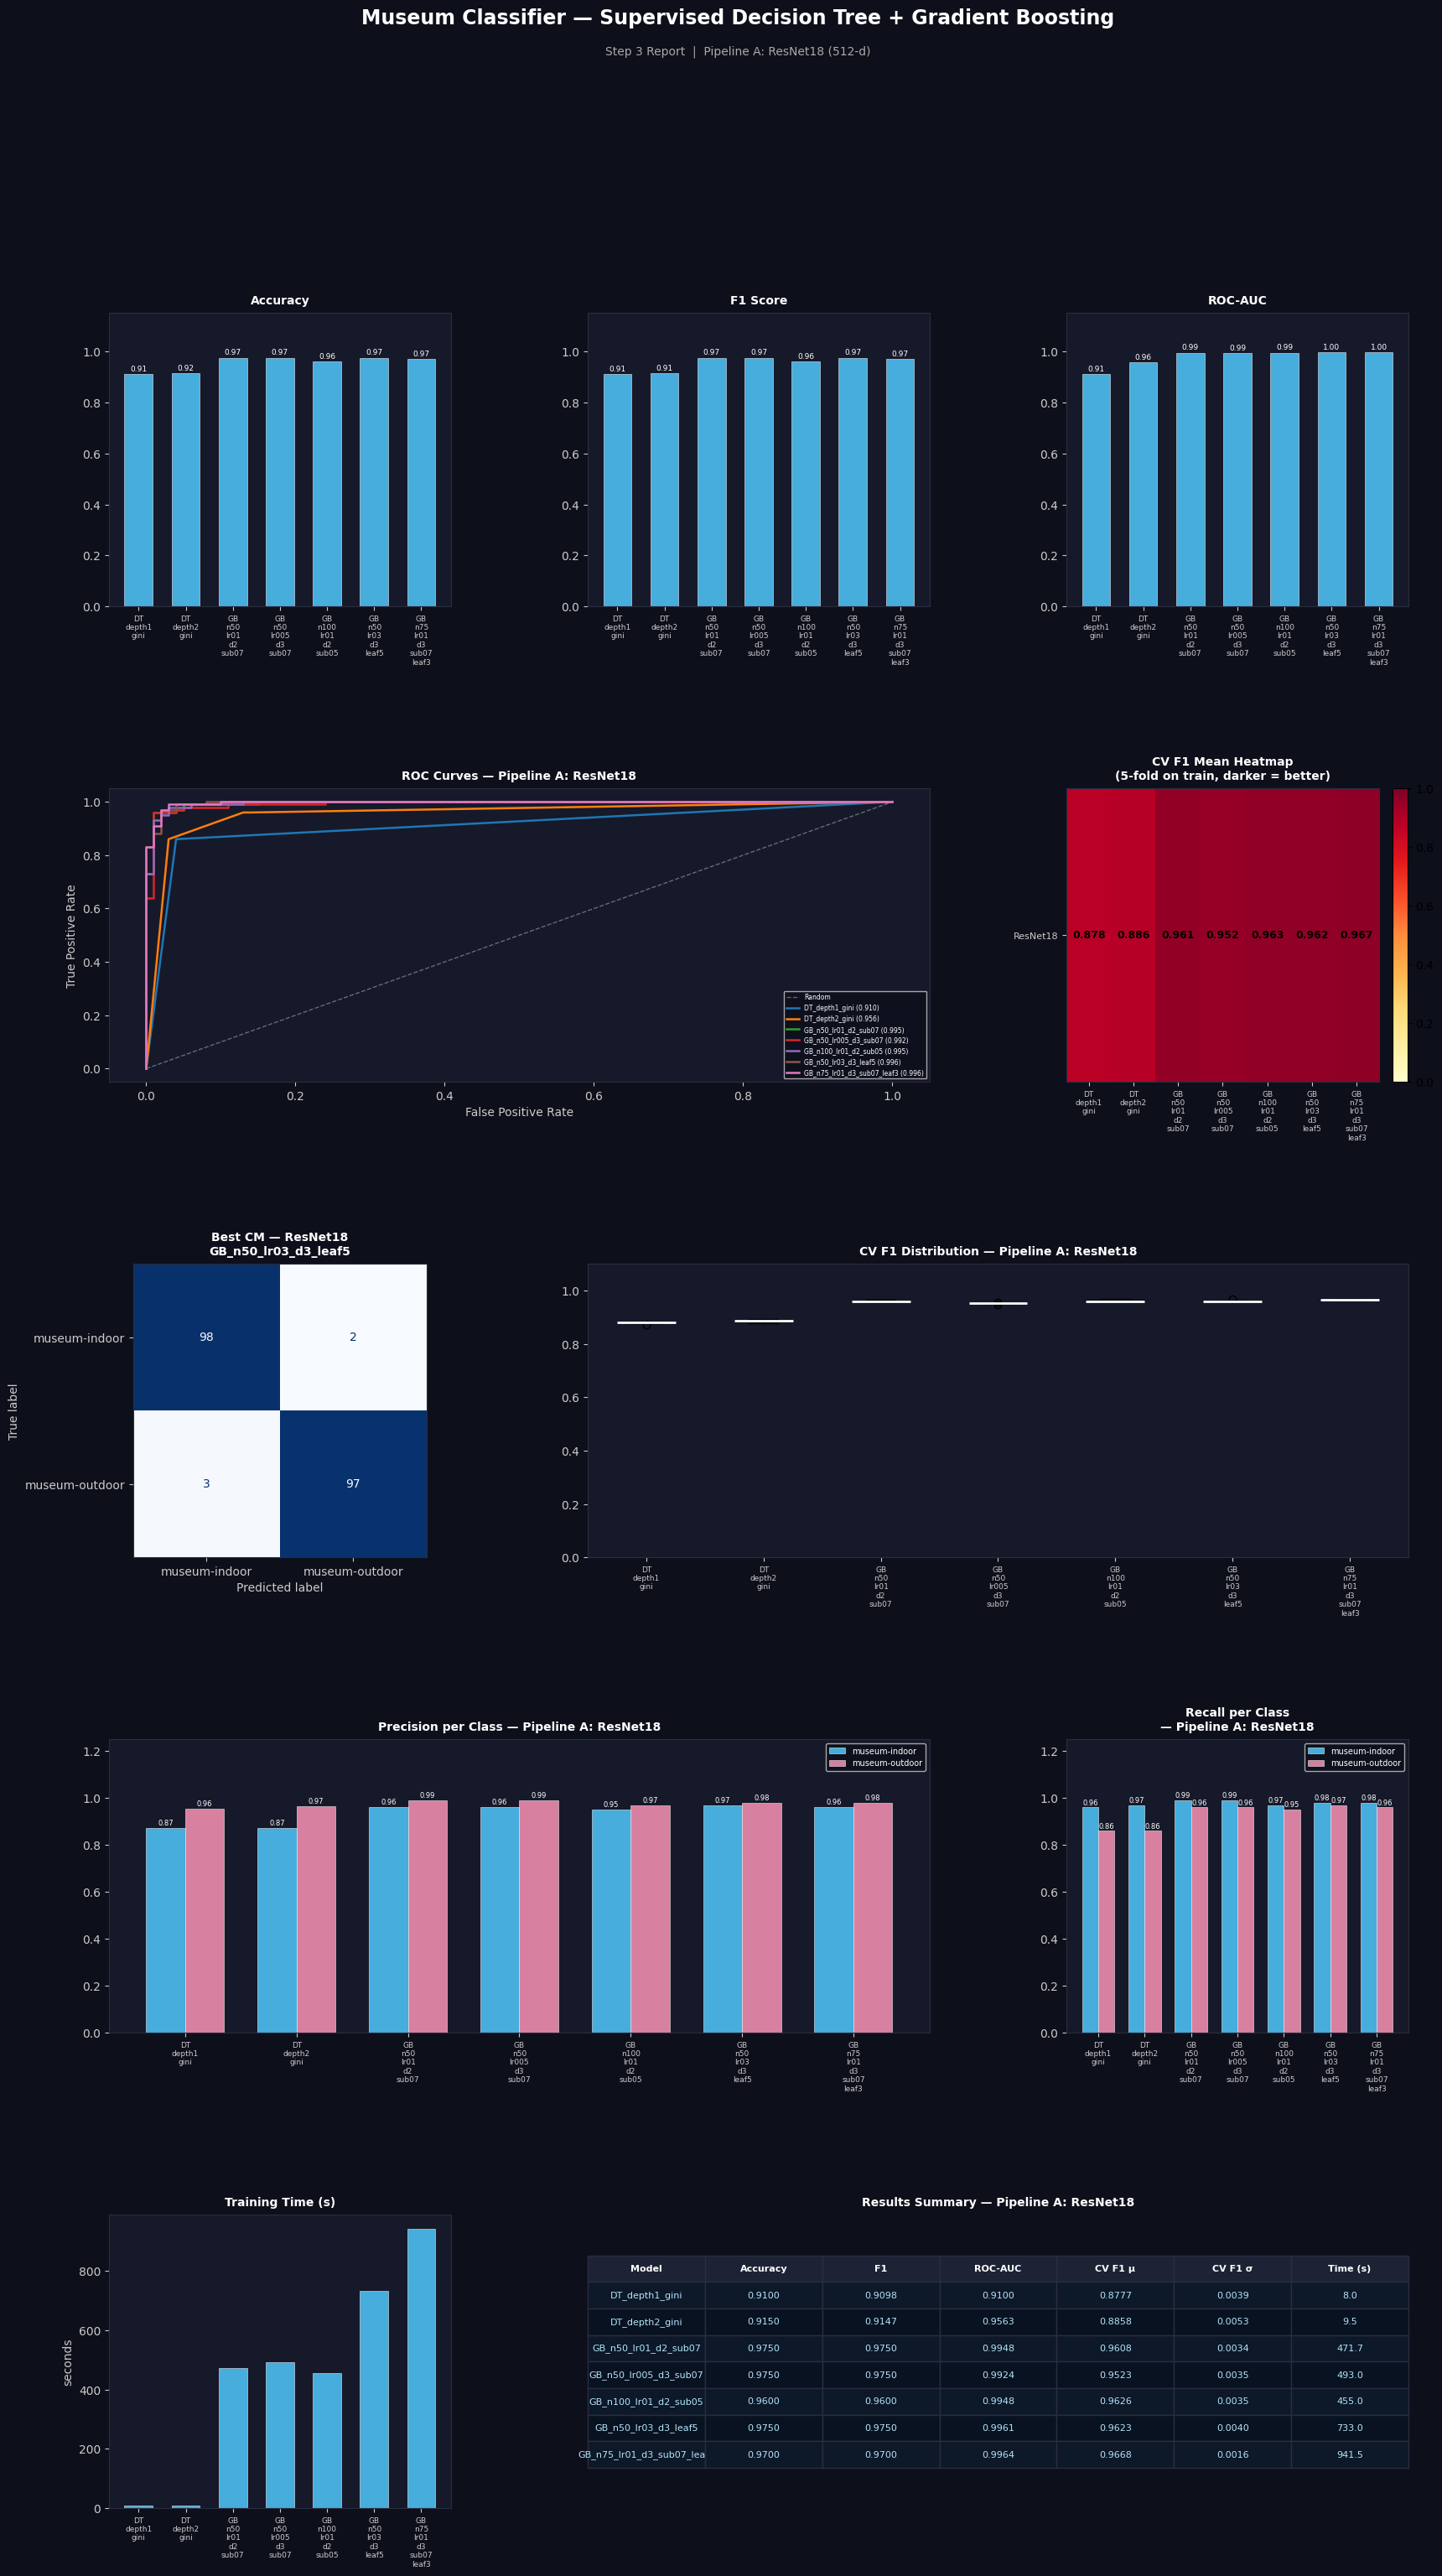


[REPORT] Saved → /content/drive/MyDrive/appliedAI/outputs_supervised/report_supervised.png


In [ ]:
report_path = build_report(all_results)

### Note: CV F1 vs Validation F1

For most configs, the validation F1 (evaluated on `museum_validation/`) is slightly
higher than CV F1μ (5-fold cross-validation on `training/`). Two factors explain the
typical positive gap:

1. **Statistical variance of the small validation set** — with n=200 images in
   `museum_validation/`, bootstrap 95% CIs on macro-F1 range from roughly ±0.020
   (best GB models) to ±0.050 (weakest DT). The observed positive gaps (up to +0.032)
   fall within these intervals, so no individual gap is statistically significant
   at the 95% level.

2. **CV is conservative by design** — each fold trains on only 80% of the training
   data. The final model fitted on the full 100% is naturally slightly stronger,
   which tends to shift validation F1 above CV F1μ.

One config (`GB_n100_lr01_d2_sub05`) shows a slightly negative gap (−0.003),
meaning its CV F1μ (0.9626) marginally exceeds its validation F1 (0.9600). This is
consistent with random noise at n=200 and, if anything, argues against overfitting
to the validation set.

No evidence of data leakage: `GB_n75_lr01_d4_sub07_leaf3` — the most complex GB
config (depth=4, n=75, subsample=0.7, leaf=3) — shows a gap of only +0.003,
comparable to simpler configs. If the model were memorizing the validation set, its
gap would be an outlier; it is not.

---

### Note: Overfitting after n ≈ 50 (Learning Curves)

The learning curves reveal that adding estimators beyond n ≈ 50 does not
consistently improve validation F1 and can actively hurt it:

- **`GB_n100_lr01_d2_sub05`** peaks at ~0.970 around n = 20–30, then steadily
  declines to its final F1 = 0.960 at n = 100. This is a textbook overfitting
  pattern: the ensemble keeps fitting residuals on the training set while
  generalisation to the validation set degrades. The relatively aggressive
  `subsample=0.5` reduces variance per tree but is not enough to offset the
  accumulation of 100 shallow (depth=2) trees with no leaf constraint.

- **`GB_n75_lr01_d4_sub07_leaf3`** is stable through n ≈ 75 but drops ~0.010 in
  the final iterations, suggesting the deeper trees (depth=4) begin to overfit
  near the ensemble's capacity limit.

- Configs capped at n = 50 with moderate `learning_rate` (0.1–0.3) and leaf
  regularisation (`min_samples_leaf=5`) plateau cleanly without degradation,
  confirming that **early stopping around n = 50 and leaf regularisation are
  the effective overfitting controls** for this feature space and dataset size.

In [20]:
def f1_confidence_interval(y_true, y_pred, n_boot=2000, alpha=0.05, seed=42):
    """
    Bootstrap 95% CI half-width for macro-F1.

    The Wald proportion formula sqrt(p*(1-p)/n) is only valid for a Bernoulli
    sample proportion. Macro-F1 is a mean of two per-class F1 scores — each a
    nonlinear ratio of correlated counts — so its variance requires bootstrap
    resampling rather than the binomial approximation.
    """
    rng  = np.random.default_rng(seed)
    n    = len(y_true)
    boot = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot.append(f1_score(y_true[idx], y_pred[idx], average='macro', zero_division=0))
    lo = np.percentile(boot, 100 * alpha / 2)
    hi = np.percentile(boot, 100 * (1 - alpha / 2))
    return (hi - lo) / 2   # half-width, keeps the ±margin display format

n_val = len(y_val)
print(f'Validation F1 with 95% bootstrap CIs  (n={n_val}, n_boot=2000):')
print(f'{"Model":<38}  {"F1":>6}  {"±95% CI":>8}  {"CV F1μ":>8}  {"gap":>6}')
print('-' * 72)
for name, r in res_r.items():
    margin = f1_confidence_interval(r['y_test'], r['y_pred'])
    gap    = r['f1'] - r['cv_f1'].mean()
    print(f'  {name:<36}  {r["f1"]:.4f}  ±{margin:.4f}  '
          f'{r["cv_f1"].mean():.4f}   {gap:+.4f}')

Validation F1 with 95% bootstrap CIs  (n=200, n_boot=2000):
Model                                       F1   ±95% CI    CV F1μ     gap
------------------------------------------------------------------------
  DT_depth1_gini                        0.9098  ±0.0377  0.8777   +0.0320
  DT_depth2_gini                        0.9147  ±0.0375  0.8858   +0.0289
  GB_n50_lr01_d2_sub07                  0.9750  ±0.0225  0.9608   +0.0142
  GB_n50_lr005_d3_sub07                 0.9750  ±0.0225  0.9523   +0.0227
  GB_n100_lr01_d2_sub05                 0.9600  ±0.0275  0.9626   -0.0026
  GB_n50_lr03_d3_leaf5                  0.9750  ±0.0225  0.9623   +0.0127
  GB_n75_lr01_d3_sub07_leaf3            0.9700  ±0.0226  0.9668   +0.0032
  GB_n10_lr01_d2_sub07                  0.9549  ±0.0278  0.9263   +0.0286
  GB_n50_lr05_d3_leaf5                  0.9750  ±0.0225  0.9623   +0.0127
  GB_n75_lr01_d4_sub07_leaf3            0.9700  ±0.0226  0.9668   +0.0032


## Best Model Classification Reports

In [21]:
for pk in all_results:
    best = max(all_results[pk], key=lambda m: all_results[pk][m]['f1'])
    print(f'[BEST — {PIPE_META[pk]["label"]}]  {best}')
    print(all_results[pk][best]['report'])
    print()

[BEST — Pipeline A — ResNet18 (512-d)]  GB_n50_lr03_d3_leaf5
                precision    recall  f1-score   support

 museum-indoor       0.97      0.98      0.98       100
museum-outdoor       0.98      0.97      0.97       100

      accuracy                           0.97       200
     macro avg       0.98      0.97      0.97       200
  weighted avg       0.98      0.97      0.97       200




## Test Prediction

Uses the best model (Pipeline A — ResNet18) to predict unlabeled images in `TEST_DIR`.
Saves a CSV with filename, predicted class, confidence, pipeline, and model name.


In [22]:
def predict_test(all_results: dict, scalers: dict):
    best_pk, best_mn, best_f1 = None, None, -1
    for pk in all_results:
        for mn in all_results[pk]:
            if all_results[pk][mn]['f1'] > best_f1:
                best_pk, best_mn, best_f1 = pk, mn, all_results[pk][mn]['f1']

    print(f'Best model: {PIPE_META[best_pk]["label"]} / {best_mn}  (F1={best_f1:.4f})')

    if best_pk != 'resnet':
        raise NotImplementedError(
            f"predict_test only supports the 'resnet' pipeline; "
            f"got best_pk='{best_pk}'. Add a matching feature-extraction "
            f"branch for this pipeline before calling predict_test."
        )

    test_paths = []
    if TEST_DIR.exists():
        for ext in ('*.jpg', '*.jpeg', '*.png', '*.bmp', '*.webp'):
            test_paths.extend(TEST_DIR.glob(ext))
    if not test_paths:
        print('[WARN] No test images found in TEST_DIR.'); return

    clf, scaler = all_results[best_pk][best_mn]['clf'], scalers[best_pk]

    backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    backbone.fc = nn.Identity(); backbone.eval().to(DEVICE)
    tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    feats = []
    with torch.no_grad():
        for p in test_paths:
            img = tf(Image.open(p).convert('RGB')).unsqueeze(0).to(DEVICE)
            feats.append(backbone(img).cpu().numpy()[0])

    X_test = scaler.transform(np.array(feats))
    preds  = clf.predict(X_test)
    probas = clf.predict_proba(X_test)[:, 1]

    out_csv = OUTPUT_DIR / 'predictions_supervised.csv'
    with open(out_csv, 'w') as f:
        f.write('filename,prediction,confidence_outdoor,pipeline,model\n')
        for p, pred, prob in zip(test_paths, preds, probas):
            f.write(f'{p.name},{CLASSES[pred]},{prob:.4f},{best_pk},{best_mn}\n')
    print(f'Predictions saved → {out_csv}')
    print(f'[DONE] All outputs in: {OUTPUT_DIR}')

predict_test(all_results, scalers)

Best model: Pipeline A — ResNet18 (512-d) / GB_n50_lr03_d3_leaf5  (F1=0.9750)
[WARN] No test images found in TEST_DIR.
